#### Principal Component Analysis

It is also known as PCA. It is an unsupervised machine learning technique based on dimensionality reduction .

The main aim of PCA is to convert all the high dimensional features or the dataset with multiple features into two features that can capture maximum variance in the dataset.

#### Problem Statement :------

(i.)    The main aim of this project is to apply PCA on the multiple features of load wine dataet and then convert it into only two features that can capture the maximum variance.

(ii.)   Then apply Logistic regression on the reduced 2d input feature dataset so as to visualize the results.

####    Step 1: Import all the necessary libraries

In [1202]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets        import  load_wine
from    sklearn.model_selection import  train_test_split,   GridSearchCV,   StratifiedKFold
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.decomposition   import  PCA
from    sklearn.linear_model    import  LogisticRegression
from    sklearn.metrics         import  accuracy_score, confusion_matrix,classification_report,precision_score,recall_score,f1_score

#### Step 2: Construct the Dataframe

In [1203]:
#### extract the data

data = load_wine()

#### Construct the dataframe from the data
df = pd.DataFrame(data.data, columns=data.feature_names)

#### Adding the target to the dataset
df['target']    =   data.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### OBSERVATIONS:

1.  The above dataset explains about all the details of the wine quality dataset.

2.  Wine Dataset Features Explanation

| Feature Name                     | One-Line Explanation                                                             |
| -------------------------------- | -------------------------------------------------------------------------------- |
| **alcohol**                      | Percentage of alcohol present in the wine.                                       |
| **malic_acid**                   | Amount of malic acid contributing to wine’s sour taste.                          |
| **ash**                          | Total mineral content remaining after burning the wine residue.                  |
| **alcalinity_of_ash**            | Measure of the alkalinity (basicity) of the ash content.                         |
| **magnesium**                    | Concentration of magnesium mineral present in the wine.                          |
| **total_phenols**                | Total amount of phenolic compounds affecting flavor and antioxidant properties.  |
| **flavanoids**                   | Quantity of flavonoids responsible for color and taste characteristics.          |
| **nonflavanoid_phenols**         | Amount of non-flavonoid phenolic compounds in the wine.                          |
| **proanthocyanins**              | Concentration of antioxidant compounds influencing bitterness and astringency.   |
| **color_intensity**              | Measure of the depth or richness of the wine color.                              |
| **hue**                          | Ratio describing the shade or tone of the wine color.                            |
| **od280/od315_of_diluted_wines** | Optical density ratio used to estimate wine quality and phenolic concentration.  |
| **proline**                      | Amount of proline amino acid present, often linked to wine maturity and quality. |
| **target**                       | Wine class/category label representing different wine cultivars.                 |


#### Step 3: Perform the Data Exploration

In [1204]:
#### get the first five rows of the dataset

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [1205]:
#### get the last five rows of the dataset

df.tail()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,2


In [1206]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 178


In [1207]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (178, 14)


In [1208]:
#### get the columns used in the dataset

df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

In [1209]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

#### OBSERVATIONS:

1.  All the independent or the input features are floating in nature.

2.  But the dependent feature or the target is integer in nature.

In [1210]:
#### get the descriptive summary statistics about each numerical column in the dataset

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


#### OBSERVATIONS:

1.  The above table explains the summary of the statistical summary for each numerical column in the dataset.

#### Step 4: Perform Feature Engineering and Data Cleaning

In [1211]:
### Rename 'od280/od315_of_diluted_wines' to 'diluted_wines' 

df.rename(columns={"od280/od315_of_diluted_wines":"diluted_wines"},inplace=True)

In [1212]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### OBSERVATIONS:

1.  The column name "od280/od315_of_diluted_wines" has been renamed to "diluted_wines" in the dataset.

In [1213]:
#### Check for all the NULL records used in the dataset

df.isnull().sum()

alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
hue                     0
diluted_wines           0
proline                 0
target                  0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1214]:
#### Check for the duplicate records in the dataset

df[df.duplicated()]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline,target


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Perform Exploratory Data Analysis (EDA)

In [1215]:
#### To get the correlation between all the numeric columns used in the dataset

df.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


#### OBSERVATIONS:

1.  The above table explains the summary about the correlation for each numerical columns used in the dataset.

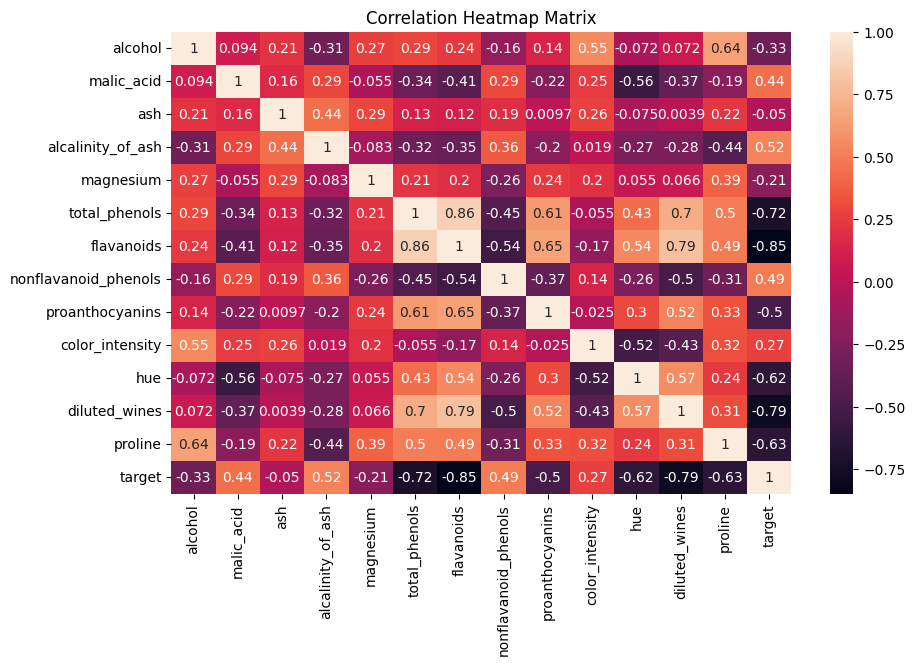

In [1216]:
#### To get the graphical representation about the correlation between all the numeric columns used in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above table explains about the correlation between all the numerical columns used in the dataset in a graphical manner.

In [1217]:
#### To get the count of all the categories in the target column

df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

#### OBSERVATIONS:

1.  There are three categories of wine used in the dataset.

#### Step 6: Divide the dataset into independent and dependent features

In [1218]:
#### independent features

X = df.drop(columns='target')

In [1219]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [1220]:
#### dependent features
Y = df['target']

In [1221]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

#### OBSERATIONS:

1.  The dataset is divided into independent features ranging from

| Feature Name                     | One-Line Explanation                                                             |
| -------------------------------- | -------------------------------------------------------------------------------- |
| **alcohol**                      | Percentage of alcohol present in the wine.                                       |
| **malic_acid**                   | Amount of malic acid contributing to wine’s sour taste.                          |
| **ash**                          | Total mineral content remaining after burning the wine residue.                  |
| **alcalinity_of_ash**            | Measure of the alkalinity (basicity) of the ash content.                         |
| **magnesium**                    | Concentration of magnesium mineral present in the wine.                          |
| **total_phenols**                | Total amount of phenolic compounds affecting flavor and antioxidant properties.  |
| **flavanoids**                   | Quantity of flavonoids responsible for color and taste characteristics.          |
| **nonflavanoid_phenols**         | Amount of non-flavonoid phenolic compounds in the wine.                          |
| **proanthocyanins**              | Concentration of antioxidant compounds influencing bitterness and astringency.   |
| **color_intensity**              | Measure of the depth or richness of the wine color.                              |
| **hue**                          | Ratio describing the shade or tone of the wine color.                            |
| **od280/od315_of_diluted_wines** | Optical density ratio used to estimate wine quality and phenolic concentration.  |
| **proline**                      | Amount of proline amino acid present, often linked to wine maturity and quality. |

2.The dataset has also the dependent feature

| Feature Name                     | One-Line Explanation                                                             |
| -------------------------------- | -------------------------------------------------------------------------------- |
| **target**                      | Category of wine quality data             .                                       |

#### Step 7: Divide the independent and dependent features into training and testing data

In [1222]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1223]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520.0
87,11.65,1.67,2.62,26.0,88.0,1.92,1.61,0.40,1.34,2.60,1.36,3.21,562.0
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0
163,12.96,3.45,2.35,18.5,106.0,1.39,0.70,0.40,0.94,5.28,0.68,1.75,675.0


In [1224]:
X_test

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline
10,14.10,2.16,2.30,18.0,105.0,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510.0
134,12.51,1.24,2.25,17.5,85.0,2.00,0.58,0.60,1.25,5.45,0.75,1.51,650.0
28,13.87,1.90,2.80,19.4,107.0,2.95,2.97,0.37,1.76,4.50,1.25,3.40,915.0
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0
62,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
66,13.11,1.01,1.70,15.0,78.0,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502.0
129,12.04,4.30,2.38,22.0,80.0,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580.0
166,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0


In [1225]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (142, 13)
Shape of the input testing  data is: (36, 13)


In [1226]:
Y_train

36     0
30     0
26     0
12     0
148    2
      ..
142    2
87     1
34     0
163    2
131    2
Name: target, Length: 142, dtype: int64

In [1227]:
Y_test

10     0
134    2
28     0
121    1
62     1
51     0
7      0
66     1
129    1
166    2
102    1
143    2
42     0
130    2
14     0
108    1
105    1
20     0
100    1
38     0
93     1
60     1
22     0
18     0
98     1
64     1
58     0
132    2
112    1
155    2
48     0
176    2
94     1
177    2
164    2
173    2
Name: target, dtype: int64

In [1228]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (142,)
Shape of the output testing  data is: (36,)


#### OBSERVATIONS:

1.  Out of 178 total records in the dataset,the dataset is divided into 

    (a.)  142 training data  ===============>  80 % of the training data

    (b.)  36  testing  data  ===============>  20 % of the testing data

2. This training and testing data is applicable for input and the output also.

#### Step 8: Perform Feature Scaling on the inputs

In [1229]:
from sklearn.preprocessing import StandardScaler

#### Create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [1230]:
X_train_scaled

array([[ 0.38580089, -0.63787118,  1.77666817, ...,  0.62437819,
         0.2529082 ,  0.46772474],
       [ 0.94851892, -0.76544542,  1.25317383, ...,  1.06715537,
         0.15104809,  1.81576773],
       [ 0.52335419, -0.51940939,  0.9540342 , ..., -0.12834302,
         0.89317174,  1.51620262],
       ...,
       [ 0.67341233, -0.49207206,  1.06621156, ...,  0.66865591,
         0.38387119,  1.1833525 ],
       [-0.01435415,  1.01148145, -0.05556203, ..., -1.19100825,
        -1.24589054, -0.21461801],
       [-0.11439291,  0.59230896,  0.13140024, ..., -0.92534194,
        -1.7260882 , -0.69725068]], shape=(142, 13))

In [1231]:
X_test_scaled

array([[ 1.41119819e+00, -1.64024018e-01, -2.42524290e-01,
        -4.82454584e-01,  3.60516237e-01,  1.09205418e+00,
         1.40697489e+00, -1.17972837e+00,  1.34974202e+00,
         3.26792693e-01,  1.33282168e+00,  8.20414517e-01,
         2.56468050e+00],
       [-5.77072182e-01, -1.00236900e+00, -4.29486554e-01,
        -6.30869988e-01, -9.83140080e-01, -4.42030055e-01,
        -1.48151070e+00,  2.01917328e+00, -6.06183246e-01,
         1.97855316e-01, -8.81064226e-01, -1.59512520e+00,
        -2.97830538e-01],
       [ 1.12358675e+00, -4.00947601e-01,  1.62709836e+00,
        -6.68914501e-02,  4.94881869e-01,  1.09205418e+00,
         1.03800775e+00,  8.29959657e-02,  2.76579486e-01,
        -2.10446378e-01,  1.33282168e+00,  1.15509773e+00,
         5.84222283e-01],
       [-1.76503247e+00, -2.64260919e-01,  3.23497383e+00,
         2.63426892e+00,  1.30107566e+00,  1.46346405e+00,
         3.26235249e+00,  9.24812189e-01,  4.66979291e-01,
         4.34240507e-01, -8.40653013e

#### OBSERVATIONS:

1.  All the input features have been scaled in the same scale range.

#### Step 9: Apply PCA on the sacled input to perform dimensionality reduction

In [1232]:
from sklearn.decomposition import PCA

#### create an object for PCA

pca = PCA(n_components=2)

#### use the PCA object, to transform the input data

X_train_scaled_pca = pca.fit_transform(X_train_scaled)

In [1233]:
X_train_scaled_pca

array([[ 1.47234303,  0.73425072],
       [ 2.6497094 ,  1.23021145],
       [ 1.88878827,  0.7924716 ],
       [ 2.21115907,  0.75345768],
       [-2.81757114,  1.64568754],
       [-3.73165137,  0.94374515],
       [ 2.00318459, -1.48866684],
       [-2.28749052,  2.37989381],
       [ 2.34494787,  1.92621606],
       [ 2.58380439,  1.01010796],
       [-0.48597588, -2.63907948],
       [-0.6498119 , -2.62837477],
       [ 2.63950743,  1.86946018],
       [ 2.0308598 ,  0.1947277 ],
       [-2.12422659,  0.44871788],
       [-1.34665718, -2.09143679],
       [-0.40560046, -1.95446872],
       [ 1.93186592, -1.24821416],
       [ 1.89218701, -0.29165108],
       [ 1.31489556,  0.00547251],
       [ 0.95484721, -0.75891277],
       [-3.35973848,  1.31941369],
       [ 3.53622075,  1.19764083],
       [-2.48691428,  2.27617037],
       [-1.03473199,  3.48245334],
       [ 2.64894947,  1.02653557],
       [ 3.27865538,  0.20604412],
       [-1.93395933, -1.53857301],
       [-0.36165946,

In [1234]:
X_test_scaled_pca = pca.transform(X_test_scaled)

In [1235]:
X_test_scaled_pca

array([[ 3.62679832,  1.32264003],
       [-2.42744213, -0.36859902],
       [ 2.32446694,  0.70472133],
       [ 1.5661514 ,  0.15789663],
       [ 0.0558136 , -1.18447232],
       [ 2.98696438,  0.7702215 ],
       [ 2.19671744,  1.66930954],
       [ 2.28476424, -1.83877522],
       [-1.72693831, -1.09491426],
       [-2.39241449,  2.58993652],
       [-0.07666835, -1.12159079],
       [-2.35698304,  0.55989254],
       [ 3.20799077,  1.26628693],
       [-1.33458689,  0.2563885 ],
       [ 4.42218488,  2.14902731],
       [ 0.1031367 , -2.29593559],
       [-1.72484717, -1.72241897],
       [ 3.23232999,  0.79924217],
       [ 0.84465434, -2.35180775],
       [ 1.56992579, -0.69057499],
       [ 0.80659608, -2.29967244],
       [-1.56727568, -1.29547343],
       [ 2.66248117, -0.0402545 ],
       [ 3.69151372,  2.57794718],
       [ 2.34262742, -1.3825759 ],
       [-0.58310639, -1.90791486],
       [ 3.268996  ,  1.8110842 ],
       [-2.92385307,  0.32302092],
       [-1.23554207,

#### OBSERVATIONS:

1.  By applying PCA on the scaled input, both the training and testing input data has been converted from 13 input features into 2 input features.

2.  This in turn performs the dimensionality reduction.

3.  By doing the dimensionality reduction, the PCA captures the maximum variance on the PCA inputs in the dataset.

#### Step 10: Visualize the PCA results


=================(a.)  Training data================================================

In [1236]:
X_train_scaled_pca

array([[ 1.47234303,  0.73425072],
       [ 2.6497094 ,  1.23021145],
       [ 1.88878827,  0.7924716 ],
       [ 2.21115907,  0.75345768],
       [-2.81757114,  1.64568754],
       [-3.73165137,  0.94374515],
       [ 2.00318459, -1.48866684],
       [-2.28749052,  2.37989381],
       [ 2.34494787,  1.92621606],
       [ 2.58380439,  1.01010796],
       [-0.48597588, -2.63907948],
       [-0.6498119 , -2.62837477],
       [ 2.63950743,  1.86946018],
       [ 2.0308598 ,  0.1947277 ],
       [-2.12422659,  0.44871788],
       [-1.34665718, -2.09143679],
       [-0.40560046, -1.95446872],
       [ 1.93186592, -1.24821416],
       [ 1.89218701, -0.29165108],
       [ 1.31489556,  0.00547251],
       [ 0.95484721, -0.75891277],
       [-3.35973848,  1.31941369],
       [ 3.53622075,  1.19764083],
       [-2.48691428,  2.27617037],
       [-1.03473199,  3.48245334],
       [ 2.64894947,  1.02653557],
       [ 3.27865538,  0.20604412],
       [-1.93395933, -1.53857301],
       [-0.36165946,

In [1237]:
#### First Principal Component of the training data

X_train_scaled_pca[:,0]

array([ 1.47234303,  2.6497094 ,  1.88878827,  2.21115907, -2.81757114,
       -3.73165137,  2.00318459, -2.28749052,  2.34494787,  2.58380439,
       -0.48597588, -0.6498119 ,  2.63950743,  2.0308598 , -2.12422659,
       -1.34665718, -0.40560046,  1.93186592,  1.89218701,  1.31489556,
        0.95484721, -3.35973848,  3.53622075, -2.48691428, -1.03473199,
        2.64894947,  3.27865538, -1.93395933, -0.36165946,  2.81397106,
        1.12847357,  2.30902351,  1.84414109,  2.42750949,  2.12307766,
       -2.34204659,  1.15054699,  1.11176967,  1.75477573,  0.46264996,
        2.76971747,  1.05930516, -2.51372064, -0.32481574,  0.2328402 ,
        1.68495199,  2.28016406,  2.9228421 , -2.62435275,  2.68202843,
        1.27109703, -1.78457277,  0.1119181 ,  1.48031857, -3.90748365,
       -0.01897839, -0.80649878, -1.4999029 , -0.20671151,  2.85795558,
        0.48656648, -0.76570241,  2.29735193,  1.71371375,  1.20221544,
        2.03225697,  2.19201278, -1.54290633,  0.80339484, -2.45

In [1238]:
#### Second Principal Component of the training data

X_train_scaled_pca[:,1]

array([ 0.73425072,  1.23021145,  0.7924716 ,  0.75345768,  1.64568754,
        0.94374515, -1.48866684,  2.37989381,  1.92621606,  1.01010796,
       -2.63907948, -2.62837477,  1.86946018,  0.1947277 ,  0.44871788,
       -2.09143679, -1.95446872, -1.24821416, -0.29165108,  0.00547251,
       -0.75891277,  1.31941369,  1.19764083,  2.27617037,  3.48245334,
        1.02653557,  0.20604412, -1.53857301, -0.57843835,  1.5104706 ,
        0.86860719,  2.34785313,  0.68582857,  1.70918674, -1.89595439,
        0.32950611,  0.88003154, -1.42587615, -0.4609211 , -2.07402604,
        0.14313775, -2.52319356, -0.07057165, -2.14519068, -2.3839699 ,
       -1.47137873, -0.20878816,  0.71154108,  0.6345181 ,  0.79687801,
        1.86015677,  1.5403611 , -1.22633262, -1.46688003,  0.67518719,
       -2.06685492, -0.10803296, -1.27031221, -2.80343858,  0.85491053,
       -1.06124113, -2.26293502,  1.28591493,  0.07423256,  0.25881296,
        1.64123438, -0.02756215, -1.87090188, -3.37123134, -1.12

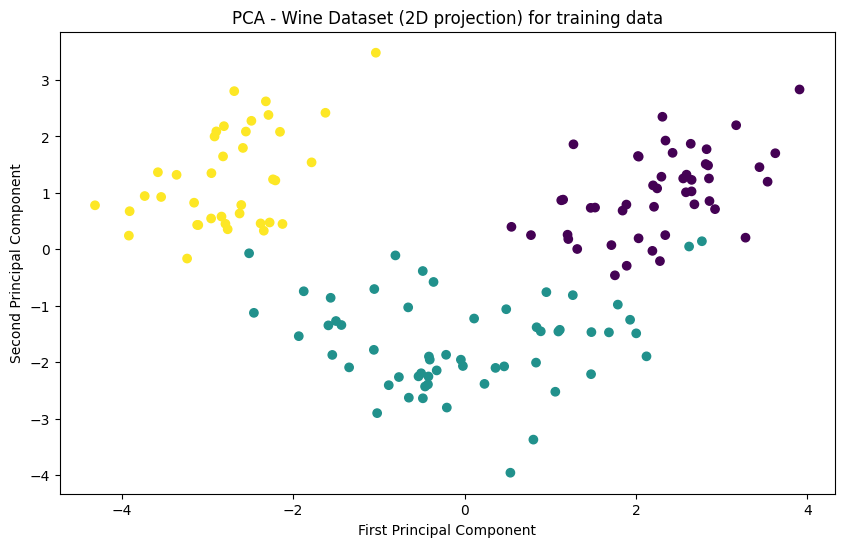

In [1239]:
plt.figure(figsize=(10,6))
#### plot the scatter plots of the training pca data
plt.scatter(X_train_scaled_pca[:,0], X_train_scaled_pca[:,1],c=Y_train)
plt.title("PCA - Wine Dataset (2D projection) for training data")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.show()

#### OBSERATIONS:

1.  The above graph explains about the scatterplot of all the traianing data points of PCA1 and PCA2.

========================(b.)  Testing data==============================================

In [1240]:
X_test_scaled_pca

array([[ 3.62679832,  1.32264003],
       [-2.42744213, -0.36859902],
       [ 2.32446694,  0.70472133],
       [ 1.5661514 ,  0.15789663],
       [ 0.0558136 , -1.18447232],
       [ 2.98696438,  0.7702215 ],
       [ 2.19671744,  1.66930954],
       [ 2.28476424, -1.83877522],
       [-1.72693831, -1.09491426],
       [-2.39241449,  2.58993652],
       [-0.07666835, -1.12159079],
       [-2.35698304,  0.55989254],
       [ 3.20799077,  1.26628693],
       [-1.33458689,  0.2563885 ],
       [ 4.42218488,  2.14902731],
       [ 0.1031367 , -2.29593559],
       [-1.72484717, -1.72241897],
       [ 3.23232999,  0.79924217],
       [ 0.84465434, -2.35180775],
       [ 1.56992579, -0.69057499],
       [ 0.80659608, -2.29967244],
       [-1.56727568, -1.29547343],
       [ 2.66248117, -0.0402545 ],
       [ 3.69151372,  2.57794718],
       [ 2.34262742, -1.3825759 ],
       [-0.58310639, -1.90791486],
       [ 3.268996  ,  1.8110842 ],
       [-2.92385307,  0.32302092],
       [-1.23554207,

In [1241]:
#### First Principal Component of the testing data

X_test_scaled_pca[:,0]

array([ 3.62679832, -2.42744213,  2.32446694,  1.5661514 ,  0.0558136 ,
        2.98696438,  2.19671744,  2.28476424, -1.72693831, -2.39241449,
       -0.07666835, -2.35698304,  3.20799077, -1.33458689,  4.42218488,
        0.1031367 , -1.72484717,  3.23232999,  0.84465434,  1.56992579,
        0.80659608, -1.56727568,  2.66248117,  3.69151372,  2.34262742,
       -0.58310639,  3.268996  , -2.92385307, -1.23554207, -3.61262626,
        2.1082766 , -2.40555443,  1.01589794, -3.19394214, -2.96601946,
       -3.36167672])

In [1242]:
#### Second Principal Component of the testing data

X_test_scaled_pca[:,1]

array([ 1.32264003, -0.36859902,  0.70472133,  0.15789663, -1.18447232,
        0.7702215 ,  1.66930954, -1.83877522, -1.09491426,  2.58993652,
       -1.12159079,  0.55989254,  1.26628693,  0.2563885 ,  2.14902731,
       -2.29593559, -1.72241897,  0.79924217, -2.35180775, -0.69057499,
       -2.29967244, -1.29547343, -0.0402545 ,  2.57794718, -1.3825759 ,
       -1.90791486,  1.8110842 ,  0.32302092, -0.76177414,  1.84617217,
        1.26272015,  2.32795704, -2.18069136,  2.80855032,  1.61443091,
        2.30035566])

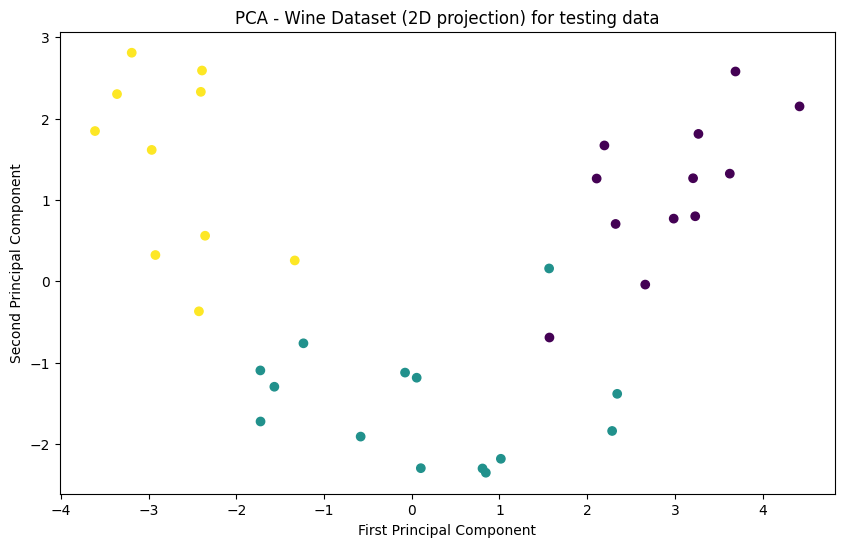

In [1243]:
plt.figure(figsize=(10,6))
#### plot the scatter plots of the testing pca data
plt.scatter(X_test_scaled_pca[:,0], X_test_scaled_pca[:,1],c=Y_test)
plt.title("PCA - Wine Dataset (2D projection) for testing data")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.show()

#### OBSERVATIONS:

1.  The above graph explains about the scatterplot of all the testing data points of PCA1 and PCA2.

#### Step 11: Train the Logistic Regression Model on the PCA reduced data

In [1244]:
X_train_scaled_pca

array([[ 1.47234303,  0.73425072],
       [ 2.6497094 ,  1.23021145],
       [ 1.88878827,  0.7924716 ],
       [ 2.21115907,  0.75345768],
       [-2.81757114,  1.64568754],
       [-3.73165137,  0.94374515],
       [ 2.00318459, -1.48866684],
       [-2.28749052,  2.37989381],
       [ 2.34494787,  1.92621606],
       [ 2.58380439,  1.01010796],
       [-0.48597588, -2.63907948],
       [-0.6498119 , -2.62837477],
       [ 2.63950743,  1.86946018],
       [ 2.0308598 ,  0.1947277 ],
       [-2.12422659,  0.44871788],
       [-1.34665718, -2.09143679],
       [-0.40560046, -1.95446872],
       [ 1.93186592, -1.24821416],
       [ 1.89218701, -0.29165108],
       [ 1.31489556,  0.00547251],
       [ 0.95484721, -0.75891277],
       [-3.35973848,  1.31941369],
       [ 3.53622075,  1.19764083],
       [-2.48691428,  2.27617037],
       [-1.03473199,  3.48245334],
       [ 2.64894947,  1.02653557],
       [ 3.27865538,  0.20604412],
       [-1.93395933, -1.53857301],
       [-0.36165946,

In [1245]:
from sklearn.linear_model import LogisticRegression

#### create an object for Logistic Regression

log = LogisticRegression(max_iter=1000)

#### using the object for logistic regression, train the model
log.fit(X_train_scaled_pca, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### OBSERVATIONS:

1.  The logistic regression model has been trained with the help of the following parameters :-------

    (a.)    X_train_scaled_pca ==================>  Input training reduced pca data

    (b.)    Y_train            ==================>  Output training data

#### Step 12: Predict the Model

In [1246]:
Y_pred = log.predict(X_test_scaled_pca)

In [1247]:
Y_pred

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

#### Step 13: Perform the Classification Evaluation Metrics

In [1248]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("=====================================Accuracy========================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0
print("Accuracy score of the model is:", ac)

print("=====================================Confusion Matrix========================================================")

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion matrix of the model is:", cm)


print("=====================================Classification Report========================================================")

cr = classification_report(Y_test, Y_pred)
print("Classification Report of the model is:", cr)

=====================================Accuracy========================================================
Accuracy score of the model is: 91.66666666666666
=====================================Confusion Matrix========================================================
Confusion matrix of the model is: [[11  1  0]
 [ 1 13  0]
 [ 0  1  9]]
=====================================Classification Report========================================================
Classification Report of the model is:               precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.87      0.93      0.90        14
           2       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



#### OBSERVATIONS:

1.  The accuracy of the Logistic Regression model with PCA on the wine dataset is 91.66 which is very high.

2.  As the accuracy is high, so the model is working fine.